In [1]:
import numpy as np
import hdf5storage
import torch
import matplotlib.pyplot as plt
from Model3_newhead import ResidualBlock, ICmosToThetaResNet, icmos_to_ms_resnet, weights_init
from d2M_function2 import MuellerMatrixFilmSingleLayer
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
import time
import copy
from thickness_predictor import ThicknessPredictor
import random

In [2]:
def compute_Iout_vectorized(d, Sencoder, Spec, Mdecoder, eps=1e-12):
    """
    计算 I_out 从 Ms, Sencoder, Spec, 和 Mdecoder，使用向量化操作。
    参数:
        Ms (torch.Tensor): 形状为 [N, 1, 1, 121, 4, 4] 的张量。
        Sencoder (torch.Tensor): 形状为 [1, 256, 256, 121, 4, 1] 的张量。
        Spec (torch.Tensor): 形状为 [1, 484]] 的张量。
        Mdecoder (torch.Tensor): 形状为 [256, 256, 484] 的张量。

    返回:
        I_out (torch.Tensor): 形状为 [N, 256, 256] 的张量。
    """

    # 扩展 Ms 到 [N, 256, 256, 121, 4, 4]

    ideal_d = torch.ones(1, 1) * d
    Ms = Mfilm(ideal_d,45)  # torch.Size([N, 4, 4, 121])
    Ms = Ms.permute(0, 3, 1, 2)  # torch.Size([1, 121, 4, 4])
    Ms = Ms.unsqueeze(1).unsqueeze(1) # torch.Size([N, 1, 1, 121, 4, 4])
    Ms = Ms.float().to(device)

    N = Ms.shape[0]
    # 扩展 Ms 到 [N, 256, 256, 121, 4, 4]

    Ms_expanded = Ms.expand(N, 256, 256, -1, -1, -1).float()  # [N, 256, 256, 121, 4, 4]

    Sencoder = Sencoder.float()

    # 执行矩阵乘法，得到 [N, 256, 256, 121, 4, 1]
    S_out = torch.matmul(Ms_expanded, Sencoder)  # [N, 256, 256, 121, 4, 1]

    # # 去除最后一个维度，得到 [N, 256, 256, 121, 4]
    S_out = S_out.squeeze(-1)  # [N, 256, 256, 121, 4]

    # # 调整维度顺序，得到 [N, 256, 256, 4, 241]
    S_out = S_out.permute(0, 1, 2, 4, 3)  # [N, 256, 256, 4, 121]

    # # 重塑为 [N, 256, 256, 484]
    S_out = S_out.reshape(N, 256, 256, -1)  # [N, 256, 256, 484]

    # # 元素级相乘
    Spec = Spec.squeeze()
    # print(Spec.shape)
    S_out_spec = S_out * Spec  # [N, 256, 256, 484]
    # print(S_out_spec.shape)

    # # # 元素级相乘并在最后一个维度求和，得到 [N, 256, 256]
    I_out = (Mdecoder * S_out_spec).sum(dim=-1)  # [N, 256, 256]

    # # # # 归一化，每个样本独立归一化
    I_out = I_out / I_out.view(N, -1).max(dim=1, keepdim=True)[0].view(N, 1, 1)  # [N, 256, 256]
    return I_out

In [3]:
def add_noise(image, noise_percentage=0.01):
    
    # 获取图像的最大值
    max_value = torch.max(image)

    # 计算噪声幅度（最大值的1%）
    noise_amplitude = max_value * noise_percentage

    # 生成与输入图像相同形状的随机噪声（均匀分布在 -noise_amplitude 到 noise_amplitude 之间）
    noise = torch.rand_like(image) * 2 * noise_amplitude - noise_amplitude

    # 将噪声添加到原始图像
    noisy_image = image + noise

    # 确保像素值不会小于0
    noisy_image = torch.clamp(noisy_image, min=0.0)

    return noisy_image

In [4]:
device = "cpu"

In [5]:
Mfilm = MuellerMatrixFilmSingleLayer(
        si_re_path=r"F:\科研项目\XueXinyuan\D2M_plus\Training\Training_Mfilm\dataset\Si_re.txt",
        si_im_path=r"F:\科研项目\XueXinyuan\D2M_plus\Training\Training_Mfilm\dataset\Si_Im.txt",
        device="cpu"
    )

M_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\dataset\Simu\M_Decoder.mat"
M_dict = hdf5storage.loadmat(M_path)
M_Decoder = M_dict["M"]
M_Decoder = torch.from_numpy(M_Decoder)
print(M_Decoder.shape)
M_Decoder = M_Decoder.permute(0, 1, 3, 2)
M_Decoder = M_Decoder.reshape(256, 256, 4*121)
print(M_Decoder.shape)

Sencoder_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\dataset\Simu\S_Encoder.mat"
Sencoder_dict = hdf5storage.loadmat(Sencoder_path)
S_Encoder = Sencoder_dict["S"] 
S_Encoder = torch.from_numpy(S_Encoder)
print(S_Encoder.shape)
S_Encoder = S_Encoder.unsqueeze(4).unsqueeze(0)
print(S_Encoder.shape)

Spec_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\dataset\Simu\spec.mat"
Spec_dict = hdf5storage.loadmat(Spec_path)
Spec = Spec_dict["spec"]
Spec = np.array(Spec, dtype=np.float64)
Spec = torch.from_numpy(Spec)
# Spec = Spec[:, 15:136]
print(Spec.shape)

torch.Size([256, 256, 121, 4])
torch.Size([256, 256, 484])
torch.Size([256, 256, 121, 4])
torch.Size([1, 256, 256, 121, 4, 1])
torch.Size([1, 484])


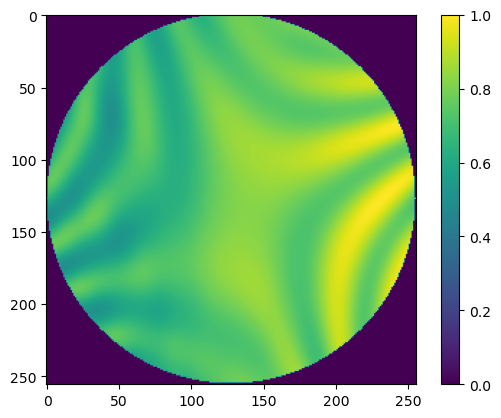

In [6]:
I_out_real = compute_Iout_vectorized(200, S_Encoder, Spec, M_Decoder, eps=1e-12)  # [N, 256, 256]
plt.figure()
plt.imshow(I_out_real.squeeze())
plt.colorbar()
plt.show()

# 随机厚度生成

Sample with Label thickness is 986.2997776654443 	 the predicted thickness is：989.7774047851562
training runtime: 4 min 20 s
##################################################################################################


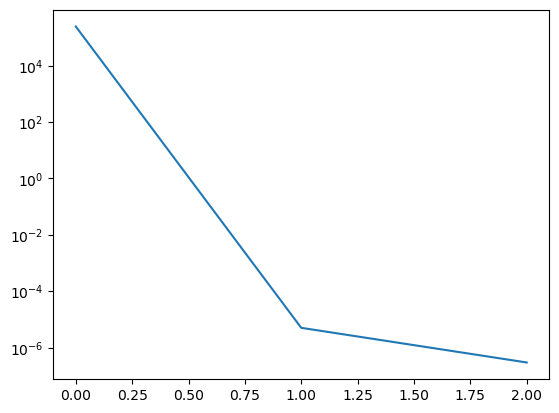

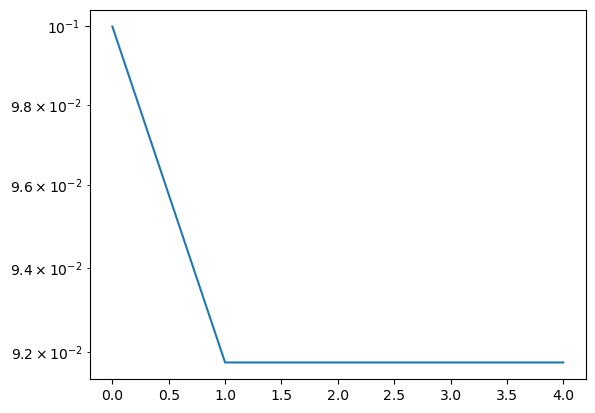

the predicted thickness is：989.7774047851562


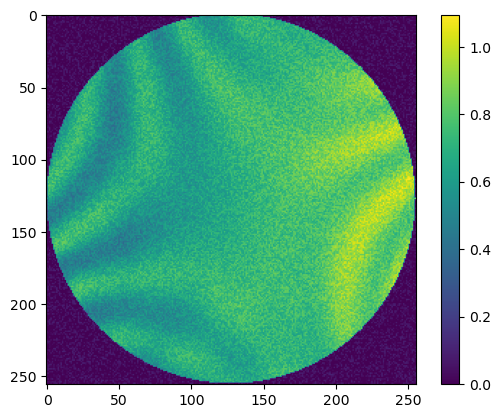

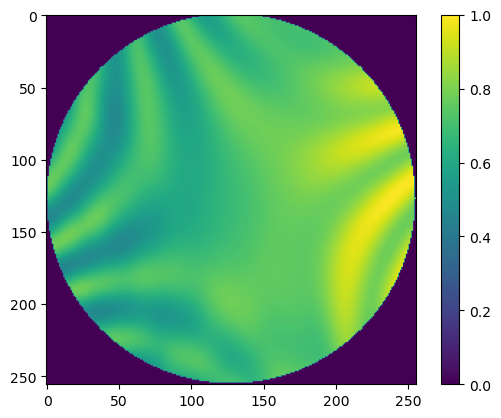

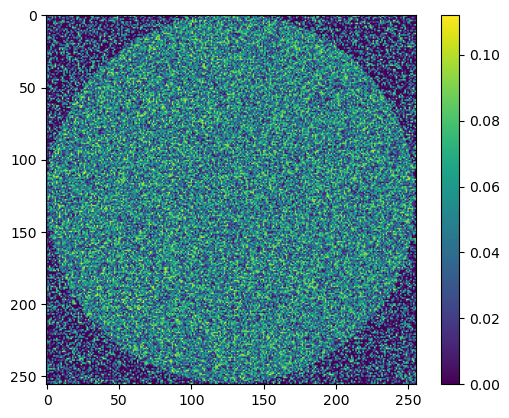

In [6]:
"""生成随即厚度的Iout"""
########################################################################################################
random_d = random.uniform(0, 1000)
# print(random_d)
I_out_real = compute_Iout_vectorized(random_d, S_Encoder, Spec, M_Decoder, eps=1e-12)  # [N, 256, 256]
# print(I_out_real.shape)
########################################################################################################

"""开始计算"""
# ---- 1) 加入噪声 ----
I_out_real = I_out_real.to(device).float()
snr_db = 0.1
I_out_real = add_noise(I_out_real, snr_db)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )

# ---- 3) 跑整体流程（pretrain+finetune）----
start = time.perf_counter()
pred_d, trained_model, I_pred, phase1_loss, phase2_loss = predictor.training_procedure(THRESH=1e-6, phase1_epochs=3, phase2_epochs=3)
elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)

# ---- 4) 打印结果 ----
print(f"Sample with Label thickness is {random_d} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")



"""开始绘图"""
#########################################################################################################
plt.figure()
plt.plot(phase1_loss)
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(phase2_loss)
plt.yscale("log")
plt.show()
#########################################################################################################
print(f"the predicted thickness is：{pred_d.item()}")
plt.figure()
plt.imshow(I_out_real.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
plt.figure()
plt.imshow(I_pred.detach().numpy().squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
residual = abs(I_out_real.detach().numpy().squeeze() - I_pred.detach().numpy().squeeze())
plt.figure()
plt.imshow(residual.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################

Sample with Label thickness is 328.7266775792331 	 the predicted thickness is：330.26983642578125
training runtime: 3 min 13 s
##################################################################################################


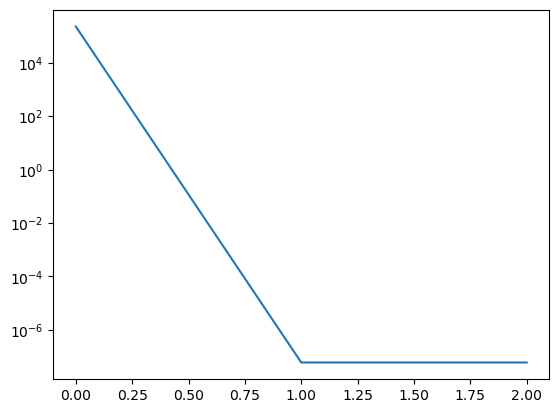

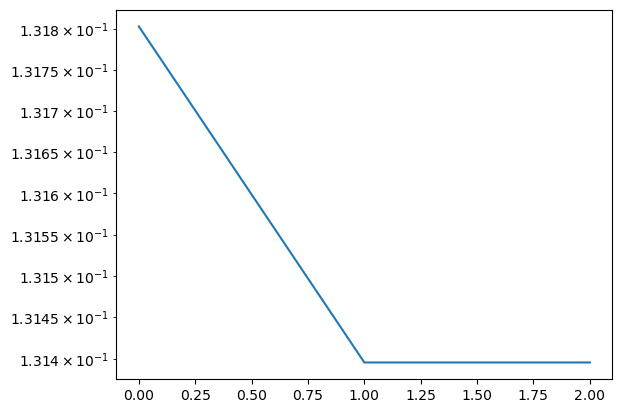

the predicted thickness is：330.26983642578125


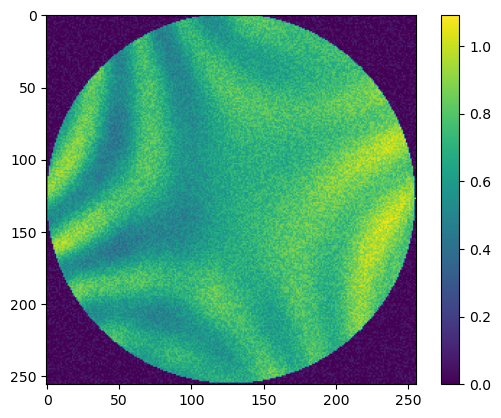

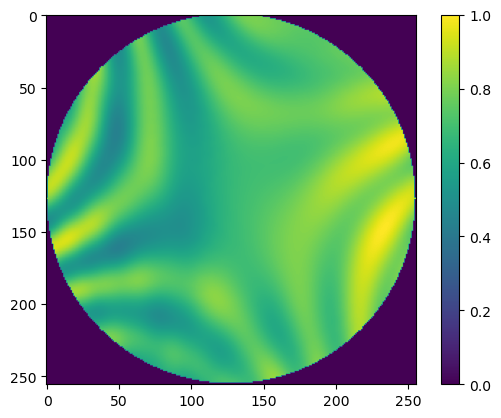

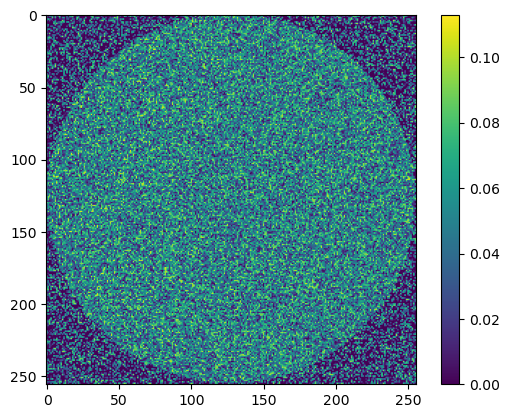

In [7]:
"""生成随即厚度的Iout"""
########################################################################################################
random_d = random.uniform(0, 1000)
# print(random_d)
I_out_real = compute_Iout_vectorized(random_d, S_Encoder, Spec, M_Decoder, eps=1e-12)  # [N, 256, 256]
# print(I_out_real.shape)
########################################################################################################

"""开始计算"""
# ---- 1) 加入噪声 ----
I_out_real = I_out_real.to(device).float()
snr_db = 0.1
I_out_real = add_noise(I_out_real, snr_db)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )

# ---- 3) 跑整体流程（pretrain+finetune）----
start = time.perf_counter()
pred_d, trained_model, I_pred, phase1_loss, phase2_loss = predictor.training_procedure(THRESH=1e-6, phase1_epochs=3, phase2_epochs=3)
elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)

# ---- 4) 打印结果 ----
print(f"Sample with Label thickness is {random_d} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")



"""开始绘图"""
#########################################################################################################
plt.figure()
plt.plot(phase1_loss)
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(phase2_loss)
plt.yscale("log")
plt.show()
#########################################################################################################
print(f"the predicted thickness is：{pred_d.item()}")
plt.figure()
plt.imshow(I_out_real.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
plt.figure()
plt.imshow(I_pred.detach().numpy().squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
residual = abs(I_out_real.detach().numpy().squeeze() - I_pred.detach().numpy().squeeze())
plt.figure()
plt.imshow(residual.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################

Sample with Label thickness is 932.4811510341422 	 the predicted thickness is：928.5527954101562
training runtime: 3 min 23 s
##################################################################################################


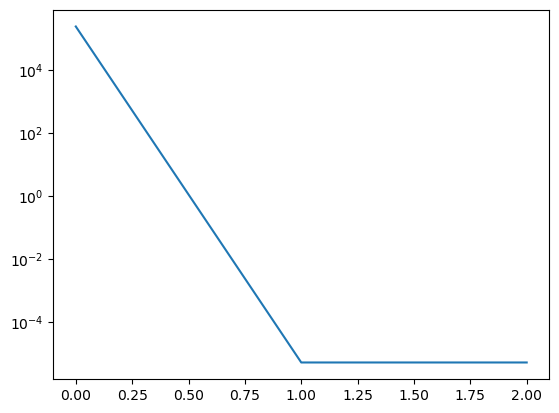

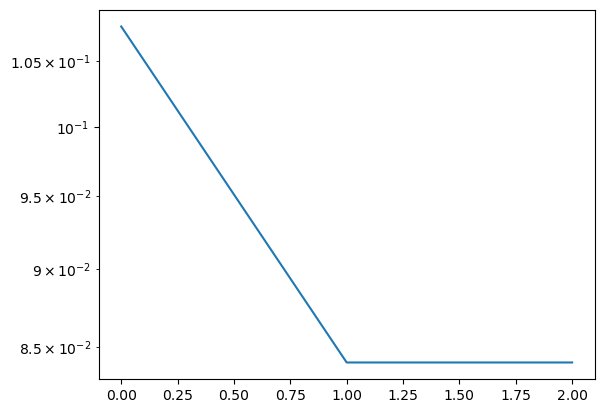

the predicted thickness is：928.5527954101562


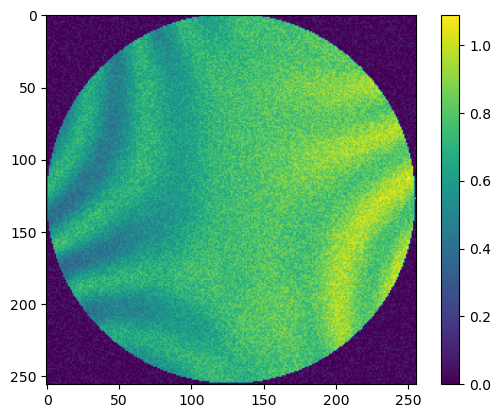

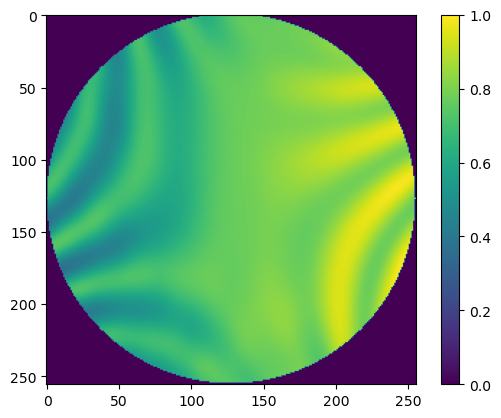

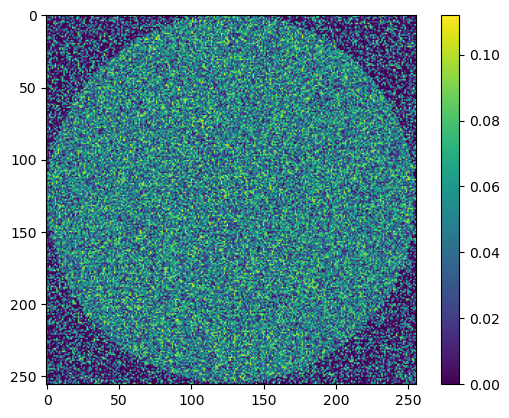

In [8]:
"""生成随即厚度的Iout"""
########################################################################################################
random_d = random.uniform(0, 1000)
# print(random_d)
I_out_real = compute_Iout_vectorized(random_d, S_Encoder, Spec, M_Decoder, eps=1e-12)  # [N, 256, 256]
# print(I_out_real.shape)
########################################################################################################

"""开始计算"""
# ---- 1) 加入噪声 ----
I_out_real = I_out_real.to(device).float()
snr_db = 0.1
I_out_real = add_noise(I_out_real, snr_db)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )

# ---- 3) 跑整体流程（pretrain+finetune）----
start = time.perf_counter()
pred_d, trained_model, I_pred, phase1_loss, phase2_loss = predictor.training_procedure(THRESH=1e-6, phase1_epochs=3, phase2_epochs=3)
elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)

# ---- 4) 打印结果 ----
print(f"Sample with Label thickness is {random_d} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")



"""开始绘图"""
#########################################################################################################
plt.figure()
plt.plot(phase1_loss)
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(phase2_loss)
plt.yscale("log")
plt.show()
#########################################################################################################
print(f"the predicted thickness is：{pred_d.item()}")
plt.figure()
plt.imshow(I_out_real.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
plt.figure()
plt.imshow(I_pred.detach().numpy().squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
residual = abs(I_out_real.detach().numpy().squeeze() - I_pred.detach().numpy().squeeze())
plt.figure()
plt.imshow(residual.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################

Sample with Label thickness is 482.74287577242046 	 the predicted thickness is：482.7429504394531
training runtime: 5 min 27 s
##################################################################################################


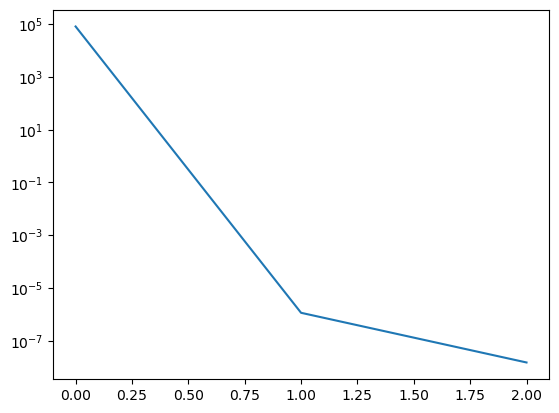

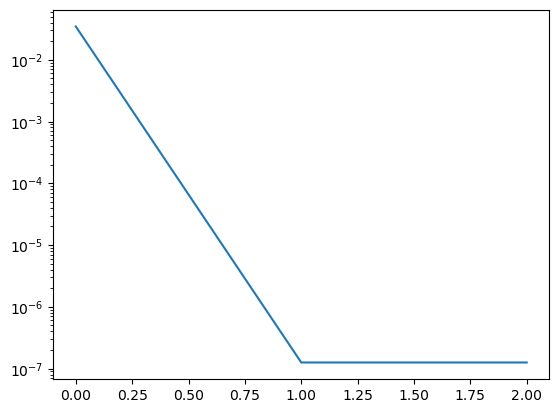

the predicted thickness is：482.7429504394531


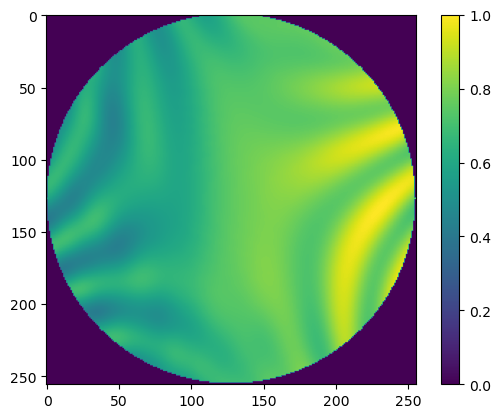

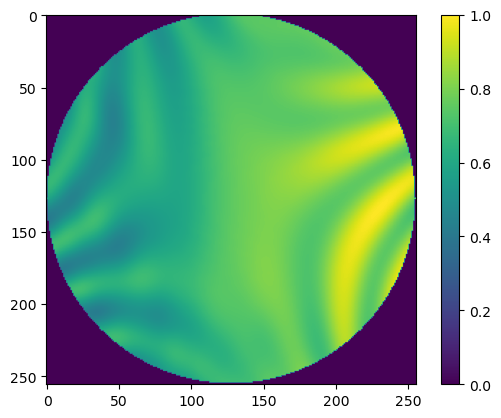

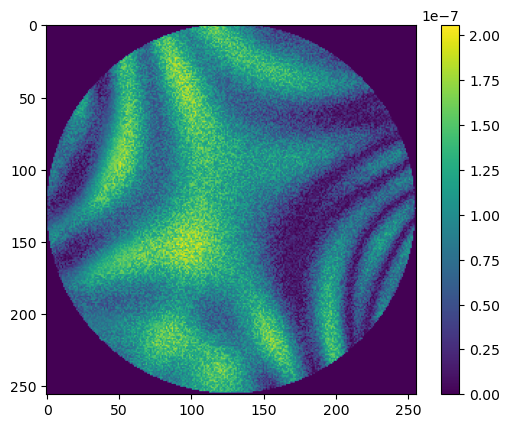

In [11]:
"""生成随即厚度的Iout"""
########################################################################################################
random_d = random.uniform(0, 1000)
# print(random_d)
I_out_real = compute_Iout_vectorized(random_d, S_Encoder, Spec, M_Decoder, eps=1e-12)  # [N, 256, 256]
# print(I_out_real.shape)
########################################################################################################

"""开始计算"""
# # ---- 1) 加入噪声 ----
I_out_real = I_out_real.to(device).float()
# snr_db = 0.1
# I_out_real = add_noise(I_out_real, snr_db)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )

# ---- 3) 跑整体流程（pretrain+finetune）----
start = time.perf_counter()
pred_d, trained_model, I_pred, phase1_loss, phase2_loss = predictor.training_procedure(THRESH=1e-6, phase1_epochs=3, phase2_epochs=3)
elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)

# ---- 4) 打印结果 ----
print(f"Sample with Label thickness is {random_d} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")



"""开始绘图"""
#########################################################################################################
plt.figure()
plt.plot(phase1_loss)
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(phase2_loss)
plt.yscale("log")
plt.show()
#########################################################################################################
print(f"the predicted thickness is：{pred_d.item()}")
plt.figure()
plt.imshow(I_out_real.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
plt.figure()
plt.imshow(I_pred.detach().numpy().squeeze())
plt.colorbar()
plt.show()
#########################################################################################################
residual = abs(I_out_real.detach().numpy().squeeze() - I_pred.detach().numpy().squeeze())
plt.figure()
plt.imshow(residual.squeeze())
plt.colorbar()
plt.show()
#########################################################################################################

# 查看预生成的固定厚度I_out

# 620 nm

In [8]:
pred_d_list = []
pred_model_list = []
pred_I_list = []

start = time.perf_counter()
# ---- 1) 拿Iout ----
thickness = 620
d_label_index = thickness-10   # 第940个 对应950nm
# 拿去950nm的Iout
I_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\薄膜\I_out_label.pt"   # 10,1000,1
I_out_label = torch.load(I_path, weights_only=True, map_location="cpu")
I_out_label = I_out_label[d_label_index]
I_out_real = I_out_label.to(device).float().unsqueeze(0)
snr_db = 0.1
I_out_real = add_noise(I_out_real, snr_db)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )
# ---- 3) 跑整体流程（pretrain+finetune）----
pred_d, trained_model, I_pred, phase1_loss, phase2_loss = predictor.training_procedure(THRESH=1e-6)

pred_d_list.append(pred_d)
pred_model_list.append(trained_model)
pred_I_list.append(I_pred)

elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)
print(f"Sample with Label thickness is {thickness} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")

Sample with Label thickness is 620 	 the predicted thickness is：621.9574584960938
training runtime: 4 min 5 s
##################################################################################################


# 660

In [9]:
pred_d_list = []
pred_model_list = []
pred_I_list = []

start = time.perf_counter()
# ---- 1) 拿Iout ----
thickness = 660
d_label_index = thickness-10   # 第940个 对应950nm
# 拿去950nm的Iout
I_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\薄膜\I_out_label.pt"   # 10,1000,1
I_out_label = torch.load(I_path, weights_only=True, map_location="cpu")
I_out_label = I_out_label[d_label_index]
I_out_real = I_out_label.to(device).float().unsqueeze(0)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )
# ---- 3) 跑整体流程（pretrain+finetune）----
pred_d, trained_model, I_pred, phase1_loss, phase2_loss = predictor.training_procedure(THRESH=1e-6)

pred_d_list.append(pred_d)
pred_model_list.append(trained_model)
pred_I_list.append(I_pred)

elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)
print(f"Sample with Label thickness is {thickness} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")

Sample with Label thickness is 660 	 the predicted thickness is：659.9998168945312
training runtime: 3 min 36 s
##################################################################################################


# 680

In [ ]:
pred_d_list = []
pred_model_list = []
pred_I_list = []

start = time.perf_counter()
# ---- 1) 拿Iout ----
thickness = 680
d_label_index = thickness-10   # 第940个 对应950nm
# 拿去950nm的Iout
I_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\薄膜\I_out_label.pt"   # 10,1000,1
I_out_label = torch.load(I_path, weights_only=True, map_location="cpu")
I_out_label = I_out_label[d_label_index]
I_out_real = I_out_label.to(device).float().unsqueeze(0)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )
# ---- 3) 跑整体流程（pretrain+finetune）----
pred_d, trained_model, I_pred = predictor.training_procedure(THRESH=1e-6)

pred_d_list.append(pred_d)
pred_model_list.append(trained_model)
pred_I_list.append(I_pred)

elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)
print(f"Sample with Label thickness is {thickness} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")


# ######################################################################################################
# print(f"the predicted thickness is：{pred_d.item()}")
# plt.figure()
# plt.imshow(I_out_real.squeeze())
# plt.colorbar()
# plt.show()
# ########################################################################################################
# plt.figure()
# plt.imshow(I_pred.detach().numpy().squeeze())
# plt.colorbar()
# plt.show()
# ########################################################################################################
# residual = abs(I_out_real.detach().numpy().squeeze() - I_pred.detach().numpy().squeeze())
# plt.figure()
# plt.imshow(residual.squeeze())
# plt.colorbar()
# plt.show()
# ########################################################################################################

# 700

In [ ]:
pred_d_list = []
pred_model_list = []
pred_I_list = []

start = time.perf_counter()
# ---- 1) 拿Iout ----
thickness = 700
d_label_index = thickness-10   # 第940个 对应950nm
# 拿去950nm的Iout
I_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\薄膜\I_out_label.pt"   # 10,1000,1
I_out_label = torch.load(I_path, weights_only=True, map_location="cpu")
I_out_label = I_out_label[d_label_index]
I_out_real = I_out_label.to(device).float().unsqueeze(0)

# ---- 2) 构建预测器 ----
predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                               Mfilm=Mfilm, 
                               device=torch.device('cpu')
                              )
# ---- 3) 跑整体流程（pretrain+finetune）----
pred_d, trained_model, I_pred = predictor.training_procedure(THRESH=1e-6)

pred_d_list.append(pred_d)
pred_model_list.append(trained_model)
pred_I_list.append(I_pred)

elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)
print(f"Sample with Label thickness is {thickness} \t the predicted thickness is：{pred_d.item()}")
print(f"training runtime: {m} min {s} s")
print("##################################################################################################")

In [ ]:
pred_d_list = []
pred_model_list = []
pred_I_list = []

for thick in range(100, 1000, 20):
    i = 1 
    start = time.perf_counter()
    
    # ---- 1) 拿Iout ----
    
    thickness = thick
    d_label_index = thickness-10   # 第940个 对应950nm
    # 拿去950nm的Iout
    I_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\薄膜\I_out_label.pt"   # 10,1000,1
    I_out_label = torch.load(I_path, weights_only=True, map_location="cpu")
    I_out_label = I_out_label[d_label_index]
    I_out_real = I_out_label.to(device).float().unsqueeze(0)
    
    
    # ---- 2) 构建预测器 ----
    predictor = ThicknessPredictor(I_out_real=I_out_real, Spec=Spec, S_Encoder=S_Encoder, M_Decoder=M_Decoder,
                                   Mfilm=Mfilm, 
                                   device=torch.device('cpu')
                                  )
    
    # ---- 3) 跑整体流程（先 finetune，不达标再走 pretrain+finetune）----
    pred_d, trained_model, I_pred = predictor.training_procedure(THRESH=1e-6)
    elapsed = int(time.perf_counter() - start)
    m, s = divmod(elapsed, 60)
    print(f"Sample with Label thickness is {thickness} \t the predicted thickness is：{pred_d.item()}")
    print(f"training runtime: {m} min {s} s")
    print("##################################################################################################")
    i += 1